In [1]:
import subprocess
subprocess.run(["pip", "install", "matplotlib", "seaborn", "wordcloud"])

CompletedProcess(args=['pip', 'install', 'matplotlib', 'seaborn', 'wordcloud'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
import os
import warnings
warnings.filterwarnings('ignore')

# Download NLTK stopwords
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords

print("✅ All libraries imported!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ayesha\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Ayesha\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


✅ All libraries imported!


In [3]:
df = pd.read_csv('WELFake_Dataset.csv')

print(f"📊 Total rows: {len(df):,}")
print(f"📋 Columns: {list(df.columns)}")
print(f"📐 Shape: {df.shape}")
df.head(5)

📊 Total rows: 72,134
📋 Columns: ['Unnamed: 0', 'title', 'text', 'label']
📐 Shape: (72134, 4)


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [4]:
print("=== MISSING VALUES BEFORE CLEANING ===")
print(df.isnull().sum())

# Remove null/empty rows
df = df.dropna(subset=['title', 'text', 'label'])

# Reset index
df = df.reset_index(drop=True)

print(f"\n✅ Rows after removing nulls: {len(df):,}")
print("\n=== MISSING VALUES AFTER CLEANING ===")
print(df.isnull().sum())

=== MISSING VALUES BEFORE CLEANING ===
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

✅ Rows after removing nulls: 71,537

=== MISSING VALUES AFTER CLEANING ===
Unnamed: 0    0
title         0
text          0
label         0
dtype: int64


In [5]:
print("=== LABEL DISTRIBUTION ===")
counts = df['label'].value_counts()
print(f"Real News  (0): {counts[0]:,}")
print(f"Fake News  (1): {counts[1]:,}")
print(f"\nTotal articles: {len(df):,}")
print(f"Balance: {counts[0]/len(df)*100:.1f}% Real | {counts[1]/len(df)*100:.1f}% Fake")

=== LABEL DISTRIBUTION ===
Real News  (0): 35,028
Fake News  (1): 36,509

Total articles: 71,537
Balance: 49.0% Real | 51.0% Fake


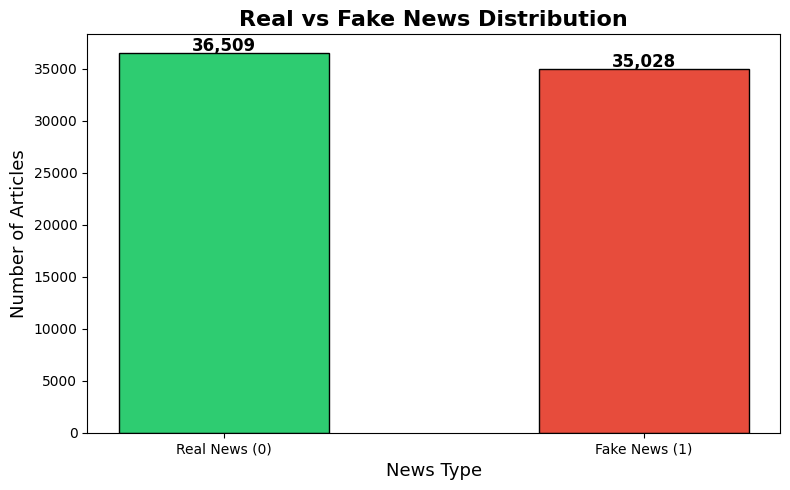

✅ Chart saved!


In [6]:
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
counts = df['label'].value_counts()

plt.bar(['Real News (0)', 'Fake News (1)'], counts.values, color=colors, edgecolor='black', width=0.5)
plt.title('Real vs Fake News Distribution', fontsize=16, fontweight='bold')
plt.xlabel('News Type', fontsize=13)
plt.ylabel('Number of Articles', fontsize=13)

for i, v in enumerate(counts.values):
    plt.text(i, v + 200, f'{v:,}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('real_vs_fake.png')
plt.show()
print("✅ Chart saved!")

In [7]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if pd.isna(text):
        return ""
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = ''.join([c for c in text if not c.isdigit()])
    # Remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

print("✅ Clean text function defined!")

# Test it
sample = "This is a SAMPLE news article, with punctuation! And numbers 123."
print(f"\nOriginal: {sample}")
print(f"Cleaned:  {clean_text(sample)}")

✅ Clean text function defined!

Original: This is a SAMPLE news article, with punctuation! And numbers 123.
Cleaned:  sample news article punctuation numbers


In [8]:
print("⏳ Cleaning text... (may take 1-2 minutes)")

df['clean_title'] = df['title'].apply(clean_text)
df['clean_text'] = df['text'].apply(clean_text)
df['combined'] = df['clean_title'] + ' ' + df['clean_text']

print("✅ Text cleaned successfully!")
df[['title', 'clean_title', 'label']].head(3)

⏳ Cleaning text... (may take 1-2 minutes)
✅ Text cleaned successfully!


,title,clean_title,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement high alert following threats c...,1
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable obama’s attorney general says cha...,1
2,"Bobby Jindal, raised Hindu, uses story of Chri...",bobby jindal raised hindu uses story christian...,0


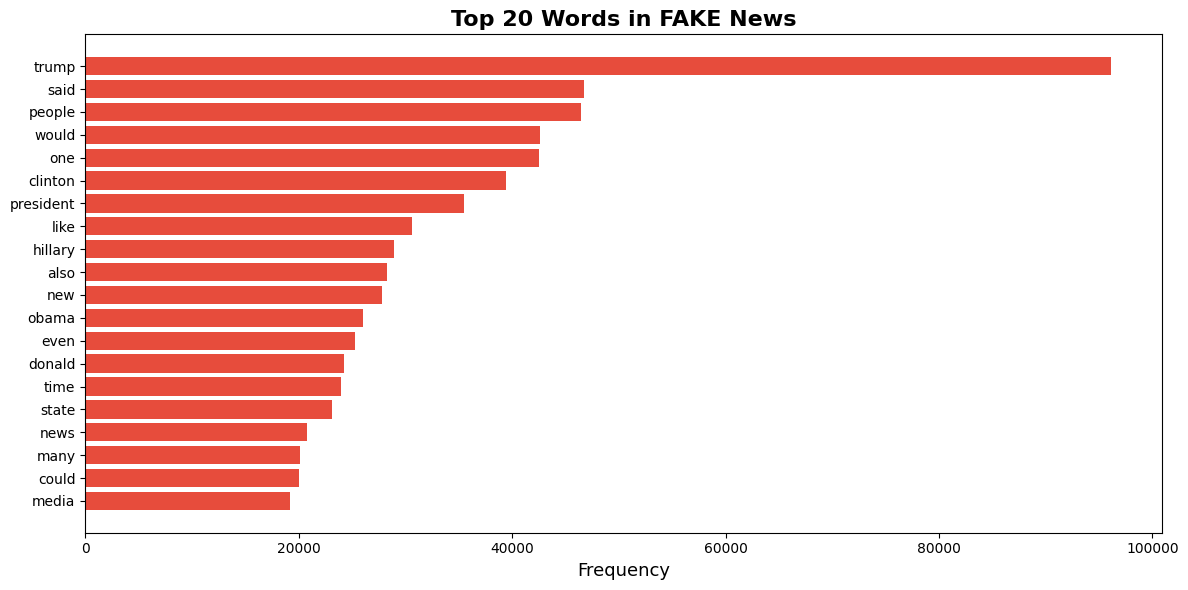

✅ Fake news word chart saved!


In [9]:
from collections import Counter

# Get all words from fake news
fake_words = ' '.join(df[df['label']==1]['clean_text'].values).split()
fake_freq = Counter(fake_words).most_common(20)

words, freqs = zip(*fake_freq)

plt.figure(figsize=(12, 6))
plt.barh(words, freqs, color='#e74c3c')
plt.title('Top 20 Words in FAKE News', fontsize=16, fontweight='bold')
plt.xlabel('Frequency', fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('fake_word_freq.png')
plt.show()
print("✅ Fake news word chart saved!")

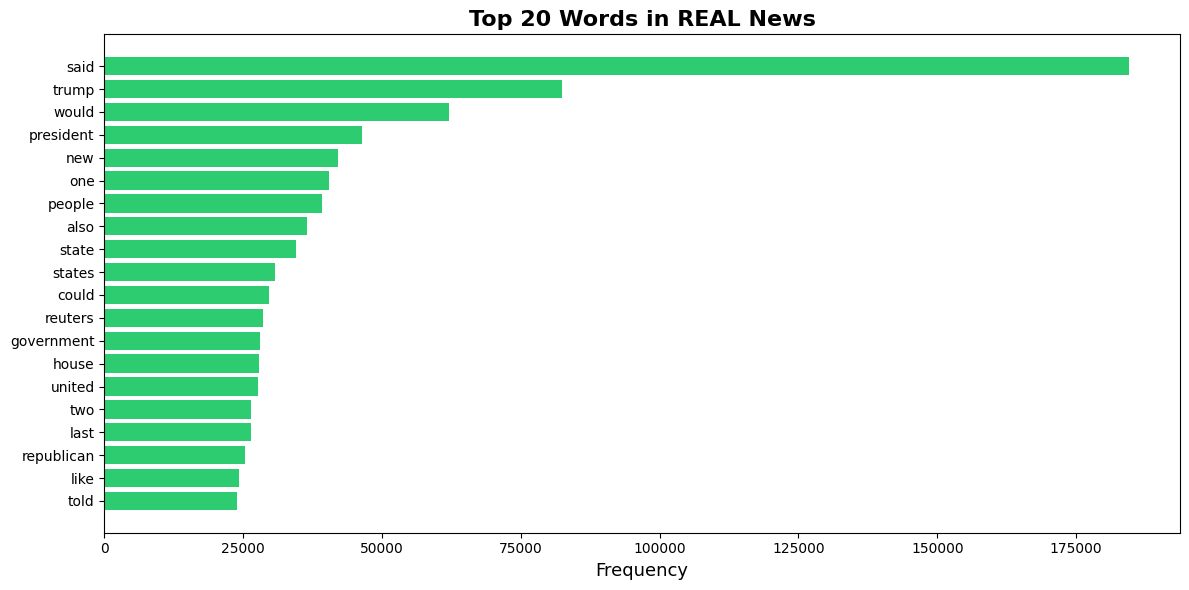

✅ Real news word chart saved!


In [10]:
# Get all words from real news
real_words = ' '.join(df[df['label']==0]['clean_text'].values).split()
real_freq = Counter(real_words).most_common(20)

words, freqs = zip(*real_freq)

plt.figure(figsize=(12, 6))
plt.barh(words, freqs, color='#2ecc71')
plt.title('Top 20 Words in REAL News', fontsize=16, fontweight='bold')
plt.xlabel('Frequency', fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('real_word_freq.png')
plt.show()
print("✅ Real news word chart saved!")

In [11]:
# Create model folder
os.makedirs('model', exist_ok=True)

# Save cleaned dataset
clean_df = df[['title', 'text', 'clean_title', 'clean_text', 'combined', 'label']]
clean_df.to_csv('model/clean_data.csv', index=False)

print("✅ clean_data.csv saved in /model folder!")
print(f"📊 Total clean rows: {len(clean_df):,}")
print(f"📁 Location: {os.path.abspath('model/clean_data.csv')}")

✅ clean_data.csv saved in /model folder!
📊 Total clean rows: 71,537
📁 Location: C:\Users\Ayesha\fake-news-project\model\clean_data.csv


In [ ]:
print("=" * 50)
print("       EDA COMPLETE — SUMMARY REPORT")
print("=" * 50)
print(f"✅ Total articles:     {len(df):,}")
print(f"✅ Real news:          {len(df[df['label']==0]):,}")
print(f"✅ Fake news:          {len(df[df['label']==1]):,}")
print(f"✅ Null rows removed:  Yes")
print(f"✅ Text lowercased:    Yes")
print(f"✅ Punctuation removed:Yes")
print(f"✅ Stopwords removed:  Yes")
print(f"✅ Charts saved:       Yes")
print(f"✅ clean_data.csv:     model/clean_data.csv")
print("=" * 50)